# **02 - Bias Analysis**

The objective of this analysis is to evaluate the integrity and fairness of the credit application dataset following the initial cleaning phase. In the context of a Data Ecosystem and Governance framework, this step ensures that the data used to train the automated credit scoring system is accurate, representative, and compliant with ethical standards, such as those outlined in the EU AI Act.

In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
file_name = 'raw_credit_applications.json' 

if os.path.exists(file_name):
    with open(file_name, 'r') as f:
        data = json.load(f)
    df_raw = pd.json_normalize(data)
    print("Good! File uploaded.")
    display(df_raw.head())
else:
    print(f"ERROR: File '{file_name}' not found.")

Good! File uploaded.


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,...,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,...,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,...,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,...,70,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,...,14,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN


In [10]:
# Listar ficheiros para garantir que o nome está correto
print("Files:", os.listdir())

file_name = 'cleaned_credit_applications.json' 

if os.path.exists(file_name):
    with open(file_name, 'r') as f:
        data = json.load(f)
    df_clean = pd.json_normalize(data)
    print("Good! File uploaded.")
    display(df_clean.head())
else:
    print(f"ERROR: File '{file_name}' not found.")

df=df_clean

Files: ['.git', '.gitignore', '.ipynb_checkpoints', '02-bias-analysis.ipynb', 'cleaned_credit_applications.json', 'cleaned_credit_data.csv', 'data', 'Data_Quality_Final.ipynb', 'notebooks', 'presentation', 'raw_credit_applications.json', 'README.md', 'reports', 'src']
Good! File uploaded.


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,notes,ssn_conflict_flag,dob_parsed,age_calculated
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,male,2001-09-03,10036,...,31212.0,False,algorithm_risk_score,not_specified,NaN,NaN,None,False,9.840960e+11,23.8
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,male,NaN,10032,...,17915.0,False,algorithm_risk_score,not_specified,NaN,NaN,None,False,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,male,NaN,10075,...,37909.0,True,NaN,vacation,3.7,59000.0,None,False,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,male,NaN,10077,...,0.0,True,NaN,not_specified,4.3,34000.0,None,False,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,male,NaN,10080,...,31763.0,False,algorithm_risk_score,not_specified,NaN,NaN,None,False,NaN,NaN


# Data Cleaning Audit

In the context of the DEGO project, the Data Cleaning Audit serves as the essential bridge between raw data ingestion and responsible model development using the cleaned data. Within a Data Governance framework, this audit ensures that the dataset is correctly "clean" and legally compliant with the standards set by the EU AI Act.

Following the initial data sanitization and technical cleaning performed by the Data Engineer, the Data Scientist assumes the role of Data Quality Auditor. This transition ensures that the dataset is not only structurally sound but also verified for statistical integrity and alignment with the project's governance standards.

In [11]:
# Calculate Nulls for Raw Data
raw_nulls = df_raw.isnull().sum()
raw_pct = (raw_nulls / len(df_raw)) * 100

# Calculate Nulls for Cleaned Data
clean_nulls = df_clean.isnull().sum()
clean_pct = (clean_nulls / len(df_clean)) * 100

# Combine into a single Comparison Table
comparison_table = pd.DataFrame({
    'Raw: Nulls': raw_nulls,
    'Raw: %': raw_pct.round(2),
    'Clean: Nulls': clean_nulls,
    'Clean: %': clean_pct.round(2)
})

# Final display
print("DATA CLEANING VERIFICATION: MISSING VALUES COMPARISON")
print(comparison_table)
print()

# Impact Analysis

# Calculation for Raw Data
raw_nulls = df_raw.isnull().sum()
raw_pct = (raw_nulls / len(df_raw)) * 100

# Calculation for Cleaned Data
clean_nulls = df_clean.isnull().sum()
clean_pct = (clean_nulls / len(df_clean)) * 100

# Create the Insight Table
quality_insight = pd.DataFrame({
    'Raw %': raw_pct.round(2),
    'Clean %': clean_pct.round(2),
    'Improvement (pp)': (raw_pct - clean_pct).round(2) # pp = percentage points
})

# Sort by where the most cleaning happened
quality_insight = quality_insight.sort_values(by='Improvement (pp)', ascending=False)

print("DATA CLEANING IMPACT ANALYSIS")
print(quality_insight)

DATA CLEANING VERIFICATION: MISSING VALUES COMPARISON
                                  Raw: Nulls  Raw: %  Clean: Nulls  Clean: %
_id                                      0.0    0.00           0.0       0.0
age_calculated                           NaN     NaN         357.0      71.4
applicant_info.date_of_birth             1.0    0.20         357.0      71.4
applicant_info.email                     0.0    0.00          11.0       2.2
applicant_info.full_name                 0.0    0.00           0.0       0.0
applicant_info.gender                    1.0    0.20           2.0       0.4
applicant_info.ip_address                5.0    1.00           4.0       0.8
applicant_info.ssn                       5.0    1.00           4.0       0.8
applicant_info.zip_code                  1.0    0.20           0.0       0.0
decision.approved_amount               210.0   41.83         208.0      41.6
decision.interest_rate                 210.0   41.83         208.0      41.6
decision.loan_approved

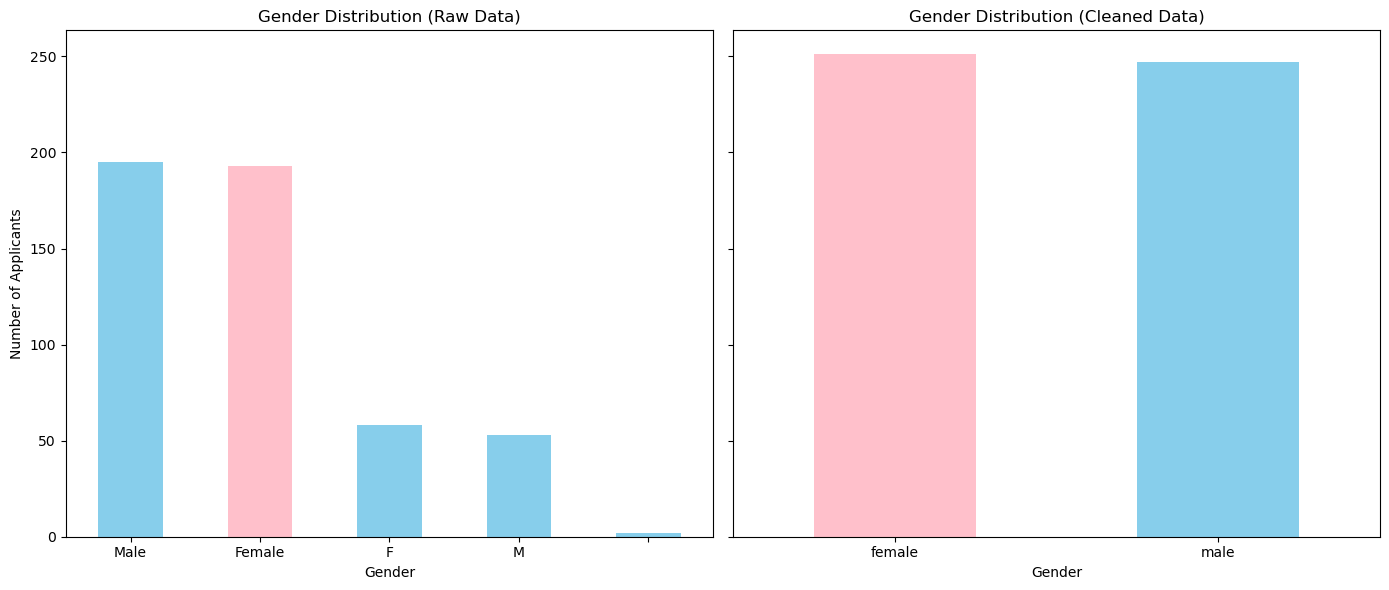

In [12]:
# Prepare the data for both dataframes
# Ensure you are using the correct column name from the raw data
raw_counts = df_raw['applicant_info.gender'].value_counts()
clean_counts = df_clean['applicant_info.gender'].value_counts()

# Setup the figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot Raw Data (Left side)
raw_colors = ['pink' if gender == 'Female' else 'skyblue' for gender in raw_counts.index]
raw_counts.plot(kind='bar', color=raw_colors, ax=ax1)
ax1.set_title('Gender Distribution (Raw Data)')
ax1.set_xlabel('Gender')
ax1.set_ylabel('Number of Applicants')
ax1.tick_params(axis='x', rotation=0)

# Plot Cleaned Data (Right side)
clean_colors = ['pink' if gender == 'female' else 'skyblue' for gender in clean_counts.index]
clean_counts.plot(kind='bar', color=clean_colors, ax=ax2)
ax2.set_title('Gender Distribution (Cleaned Data)')
ax2.set_xlabel('Gender')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Consistency Problem Corrected

As we can see the consistency issue related to the Gender variable was successfully corrected in the 'Data Cleaning' Process.
On the df_cleaned the values "F" and "M" were correctly allocated to "female" and "male", respectively.

In [13]:
print("Columns in RAW data:")
print(df_raw.columns.tolist())

print("\nColumns in CLEANED data:")
print(df_clean.columns.tolist())

Columns in RAW data:
['_id', 'spending_behavior', 'processing_timestamp', 'applicant_info.full_name', 'applicant_info.email', 'applicant_info.ssn', 'applicant_info.ip_address', 'applicant_info.gender', 'applicant_info.date_of_birth', 'applicant_info.zip_code', 'financials.annual_income', 'financials.credit_history_months', 'financials.debt_to_income', 'financials.savings_balance', 'decision.loan_approved', 'decision.rejection_reason', 'loan_purpose', 'decision.interest_rate', 'decision.approved_amount', 'financials.annual_salary', 'notes']

Columns in CLEANED data:
['_id', 'spending_behavior', 'processing_timestamp', 'applicant_info.full_name', 'applicant_info.email', 'applicant_info.ssn', 'applicant_info.ip_address', 'applicant_info.gender', 'applicant_info.date_of_birth', 'applicant_info.zip_code', 'financials.annual_income', 'financials.credit_history_months', 'financials.debt_to_income', 'financials.savings_balance', 'decision.loan_approved', 'decision.rejection_reason', 'loan_purp

In [19]:
# Define logical boundaries
MIN_INCOME = 0
MIN_MONTHS = 0

# PRE-AUDIT: Convert RAW data to numeric to allow comparison
raw_income_numeric = pd.to_numeric(df_raw['financials.annual_income'], errors='coerce')
raw_months_numeric = pd.to_numeric(df_raw['financials.credit_history_months'], errors='coerce')

# Audit Raw Data for Range Issues
raw_invalid_income = raw_income_numeric[raw_income_numeric < MIN_INCOME]
raw_invalid_months = raw_months_numeric[raw_months_numeric < MIN_MONTHS]

# Audit Cleaned Data (already numeric, so no conversion needed)
clean_invalid_income = df_clean[df_clean['financials.annual_income'] < MIN_INCOME]
clean_invalid_months = df_clean[df_clean['financials.credit_history_months'] < MIN_MONTHS]

# Create Comparison Summary
range_audit = pd.DataFrame({
    'Metric': ['Negative Annual Income', 'Negative Credit History Months'],
    'Raw': [len(raw_invalid_income), len(raw_invalid_months)],
    'Cleaned': [len(clean_invalid_income), len(clean_invalid_months)]
})

print("DATA QUALITY: RANGE CONSTRAINT VERIFICATION")
print(range_audit)

DATA QUALITY: RANGE CONSTRAINT VERIFICATION
                           Metric  Raw  Cleaned
0          Negative Annual Income    0        0
1  Negative Credit History Months    2        0
